# Анализ данных (EDA) для проекта Аналитическая платформа факторов ДТП

Исследуются данные за период с 01.01.2015 по 30.11.2025 гг. (именно за этот период есть данные в ГИБДД на момент исследования).

*Автор:* **Зайцев Виталий**  
*Дата:* **20.02.2026 г.**

## Этап 1. Загрузка и подготовка данных.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool
import psycopg2
import os
from dotenv import dotenv_values
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаю данные из csv, т.к. провайдер заблокировал доступ к supabase
df_acc = pd.read_csv("accidents_rows.csv", dtype='str')
df_det = pd.read_csv("accident_details_rows.csv", dtype='str')
df_ts = pd.read_csv("vehicles_rows.csv", dtype='str')
df_part = pd.read_csv("participants_rows.csv", dtype='str')
df_weather_code = pd.read_csv("weather_codes_rows.csv")
df_weather = pd.read_csv("raw_weather_hourly_rows.csv")

In [3]:
# объединяю дтп и детали
df_main = df_acc.drop(columns=['created_at']).merge(df_det.drop(columns=['region_id', 'district_id', 'created_at']), on='card_id')
df_main.head().T

,0,1,2,3,4
card_id,156917266,157393227,157395833,157395835,157397417
region_id,03,03,03,03,03
district_id,03401,03401,03401,03401,03401
district_name,Краснодар,Краснодар,Краснодар,Краснодар,Краснодар
accident_date,2015-01-01,2015-01-04,2015-01-04,2015-01-03,2015-01-03
accident_time,14:00:00,08:00:00,12:20:00,20:00:00,17:40:00
accident_type,Наезд на пешехода,Столкновение,Столкновение,Наезд на пешехода,Наезд на пешехода
killed_cnt,0,0,0,0,1
vehicles_count,1,2,2,1,1
participants_count,3,4,3,2,2


In [4]:
# добавляю в df_main столбец datetime с округлением вниз
df_main['full_datetime'] = pd.to_datetime(df_main['accident_date'] + ' ' + df_main['accident_time'])
df_main['accident_hour'] = df_main['full_datetime'].dt.floor('h')
df_main = df_main.drop(columns=['full_datetime'])
# присоединяю погоду
df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'])
df_full = df_main.merge(df_weather, left_on=['district_name', 'accident_hour'], right_on=['city', 'timestamp']) 
# присоединяю участников
df_analysis = df_full.merge(df_part, on='card_id')


In [5]:
# удаляю лишние столбцы
df_analysis_end = df_analysis.drop(columns=['region_id_x', 'district_id_x', 'city', 'latitude_y', 'longitude_y', 'timestamp', 'visibility', 
                                            'source', 'loaded_at', 'is_processed', 'latitude_x', 'longitude_x', 'id',
                                           'region_id_y', 'district_id_y', 'created_at', 'injured_card_id', 'seat_group'])
# добавляю колонку с описанием кодов погоды
df_analysis_end = df_analysis_end.merge(
    df_weather_code[['weather_code', 'description']], 
    on='weather_code', 
    how='left'
)
# переименовываю столбец с описанием
df_analysis_end = df_analysis_end.rename(columns={'description': 'weather_description'})

In [6]:
# привожу столбцы к нужным типам данных
df_analysis_end = df_analysis_end.astype({
    'killed_cnt': 'int',
    'vehicles_count': 'int',
    'participants_count': 'int',
    'wounded_cnt': 'int',
    'kilometer_mark': 'float',
    'kilometer': 'float',    
    'driving_exp': 'int',
    'safety_belt_used': 'bool'
})

In [7]:
# смотрю кол-во ДТП
print(f'Всего ДТП: {df_analysis_end['card_id'].nunique()}')

Всего ДТП: 12651


In [8]:
# смотрю, как соответствуют описания погоды из ГИБДД и из open-meteo
pd.crosstab(df_analysis_end['weather_conditions'], df_analysis_end['weather_description'])

weather_description,Clear sky,Dense drizzle,Heavy rain,Heavy snow fall,Light drizzle,Mainly clear,Moderate drizzle,Moderate rain,Moderate snow fall,Overcast,Partly cloudy,Slight rain,Slight snow fall
weather_conditions,,,,,,,,,,,,,
Дождь,12,90,0,8,395,43,186,32,23,252,65,117,43
Дождь; Пасмурно,0,6,0,0,68,6,24,6,0,39,12,17,0
Дождь; Снегопад,0,0,0,0,0,0,0,0,0,0,0,0,7
Пасмурно,814,67,1,4,777,586,271,47,39,2967,550,79,109
Пасмурно; Снегопад,0,0,0,0,0,0,0,0,0,4,0,0,1
Пасмурно; Температура выше +30С,1,3,0,0,0,0,0,0,0,2,2,0,0
Пасмурно; Туман,10,0,0,0,0,2,0,0,0,4,4,0,0
Снегопад,0,2,0,13,4,0,6,0,64,63,1,2,37
Температура выше +30С; Ясно,134,0,0,0,8,51,3,0,0,5,16,0,0


Видно, что описания погоды у ГИБДД часто разнятся с показаниями open-meteo, возможно - человеческий фактор (либо не верно выбрал сотрудник описание, либо вообще не выбирал и оно подставилось автоматически). Буду использовать описание погоды из столбца weather_description (open-meteo).

In [9]:
def translate_weather_description(df):
    """
    Добавляет столбец с русским переводом погоды.
    Вход: DataFrame со столбцом 'weather_description'
    Выход: DataFrame с новым столбцом 'weather_description_ru'
    """
    
    # Словарь соответствия английских описаний (Open-Meteo) и русских терминов
    # Основано на Open-Meteo кодах
    weather_mapping = {
        'Clear sky': 'Ясно',
        'Mainly clear': 'Преимущественно ясно',
        'Partly cloudy': 'Переменная облачность',
        'Overcast': 'Пасмурно',
        'Fog': 'Туман',
        'Depositing rime fog': 'Изморозь',
        
        # Морось
        'Light drizzle': 'Слабая морось',
        'Moderate drizzle': 'Умеренная морось',
        'Dense drizzle': 'Сильная морось',
        'Light freezing drizzle': 'Слабая ледяная морось',
        'Dense freezing drizzle': 'Сильная ледяная морось',
        
        # Дождь
        'Slight rain': 'Слабый дождь',
        'Moderate rain': 'Умеренный дождь',
        'Heavy rain': 'Сильный дождь',
        'Light freezing rain': 'Слабый ледяной дождь',
        'Heavy freezing rain': 'Сильный ледяной дождь',
        
        # Снег
        'Slight snow fall': 'Слабый снег',
        'Moderate snow fall': 'Умеренный снег',
        'Heavy snow fall': 'Сильный снег',
        'Snow grains': 'Снежная крупа',
        
        # Ливни
        'Slight rain showers': 'Слабый ливень',
        'Moderate rain showers': 'Умеренный ливень',
        'Violent rain showers': 'Сильный ливень',
        'Slight snow showers': 'Слабый снегопад',
        'Heavy snow showers': 'Сильный снегопад',
        
        # Гроза
        'Thunderstorm': 'Гроза',
        'Thunderstorm with slight hail': 'Гроза с градом',
        'Thunderstorm with heavy hail': 'Гроза с сильным градом'
    }
    
    # Создаю новый столбец, мапя значения из старого через словарь
    # fillna('Неизвестно') обработает случаи, если в данных попадется что-то новое
    df['weather_description_ru'] = df['weather_description'].map(weather_mapping).fillna('Неизвестно')
    
    return df

In [10]:
df_analysis_end = translate_weather_description(df_analysis_end)

# Проверка результата:
print(df_analysis_end[['weather_description', 'weather_description_ru']].head(10).drop_duplicates())

  weather_description weather_description_ru
0           Clear sky                   Ясно
1        Mainly clear   Преимущественно ясно
5            Overcast               Пасмурно
8       Dense drizzle         Сильная морось
9       Light drizzle          Слабая морось


In [11]:
df_analysis_end['weather_description_ru'].value_counts()

weather_description_ru
Ясно                     9148
Пасмурно                 7435
Преимущественно ясно     3092
Переменная облачность    2434
Слабая морось            1869
Умеренная морось          639
Слабый дождь              278
Слабый снег               217
Сильная морось            194
Умеренный снег            137
Умеренный дождь           115
Сильный снег               27
Сильный дождь               1
Name: count, dtype: int64

In [12]:
# делаю укрупненные категории по погоде
def get_weather_category(ru_description):
    if ru_description in ['Ясно', 'Преимущественно ясно']:
        return 'Ясно'
    elif ru_description in ['Переменная облачность', 'Пасмурно']:
        return 'Облачно'
    elif 'дождь' in ru_description.lower() or 'ливень' in ru_description.lower() or 'морось' in ru_description.lower():
        return 'Дождь'
    elif 'снег' in ru_description.lower():
        return 'Снег'        
    else:
        return 'Прочее'

In [13]:
# добовляю столбец с категориями погоды
df_analysis_end['weather_category'] = df_analysis_end['weather_description_ru'].apply(get_weather_category)

In [14]:
# делаю укрупненные категории состояния дороги
def group_road_condition(condition):
    if condition == 'Сухое':
        return 'Сухое'
    elif condition in ['Мокрое', 'Залитое (покрытое) водой']:
        return 'Мокрое'
    elif condition in ['Заснеженное', 'Со снежным накатом']: 
        return 'Снежное'
    elif condition in ['Гололедица', 'Обработанное противогололедными материалами']:
        # "Обработанное" почти всегда означает, что была угроза гололеда
        return 'Гололедица'
    else:
        return 'Прочее'

In [15]:
# добавляю столбец с категориями состояния дороги
df_analysis_end['road_condition_group'] = df_analysis_end['road_surface_condition'].apply(group_road_condition)
# добавляю столбец с общим кол-вом пострадавших (ранен + погиб)
df_analysis_end['total_victims'] = df_analysis_end['killed_cnt'] + df_analysis_end['wounded_cnt']

Теперь собираю окончательный датафрейм, где будет одна строка - одно ДТП. В качестве участника в этой одной строке выберем водителя, нарушившего правила (приоритет), если такого нет, то первого по списку в поле `participant_sequence` (номер участника ДТП).

In [16]:
# Создаю флаг наличия нарушения
# (True, если нарушение есть и оно не "Нет нарушений")
df_analysis_end['is_guilty'] = (
    df_analysis_end['violations'].notna() & 
    (~df_analysis_end['violations'].str.strip().isin(['Нет нарушений', 'Нет нарушения', '-']))
)

# Фильтрую только водителей
drivers_df = df_analysis_end[df_analysis_end['participant_role'] == 'Водитель'].copy()

# Сортирую датафрейм
# Сортирую по card_id, а внутри аварии — сначала виновных (is_guilty=True идет первым, т.к. True > False, поэтому сортировка по убыванию),
# а потом по порядку участника
drivers_df = drivers_df.sort_values(['card_id', 'is_guilty', 'participant_sequence'], ascending=[True, False, True])

# Удаляю дубликаты, оставляя первую строку (она теперь либо виновник, либо первый водитель)
df_final = drivers_df.drop_duplicates(subset='card_id', keep='first')

# Проверка
print(f"Размер итогового датасета: {len(df_final)}")
print(f"Кол-во уникальных ДТП: {df_final['card_id'].nunique()}")

Размер итогового датасета: 12651
Кол-во уникальных ДТП: 12651


In [17]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12651 entries, 0 to 25585
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   card_id                  12651 non-null  object        
 1   district_name            12651 non-null  object        
 2   accident_date            12651 non-null  object        
 3   accident_time            12651 non-null  object        
 4   accident_type            12651 non-null  object        
 5   killed_cnt               12651 non-null  int64         
 6   vehicles_count           12651 non-null  int64         
 7   participants_count       12651 non-null  int64         
 8   wounded_cnt              12651 non-null  int64         
 9   unified_accident_number  6467 non-null   object        
 10  lighting_conditions      12651 non-null  object        
 11  road_surface_condition   12651 non-null  object        
 12  road_condition           12651 non-nu

---

## Этап 2. Анализ 

### 1. "Погода + ДТП"

In [18]:
# разбиваю данные на 2 города
df_acc_kr = df_final[df_final['district_name'] == 'Краснодар']
df_acc_him = df_final[df_final['district_name'] == 'Химки']
print(f'Всего ДТП в Краснодаре: {len(df_acc_kr)}')
print(f'Всего ДТП в Химках: {len(df_acc_him)}')
print(f'В Краснодаре в {round(len(df_acc_kr) / len(df_acc_him), 1)} больше ДТП')

Всего ДТП в Краснодаре: 11742
Всего ДТП в Химках: 909
В Краснодаре в 12.9 больше ДТП


Видно, что в Краснодаре за период 10 лет почти в 13 раз больше ДТП, чем в Химках. Вероятнее всего это связано с кол-вом населения в этих городах:  
 - Краснодар - 1 262 725 человек
 - Химки - 280 399 человек

т.е. в Краснодаре в 4,5 раза больше населения.

Следовательно, чтобы не было перекосов в выводах, нельзя делать общий анализ, нужно проводить отдельный анализ по каждому городу.

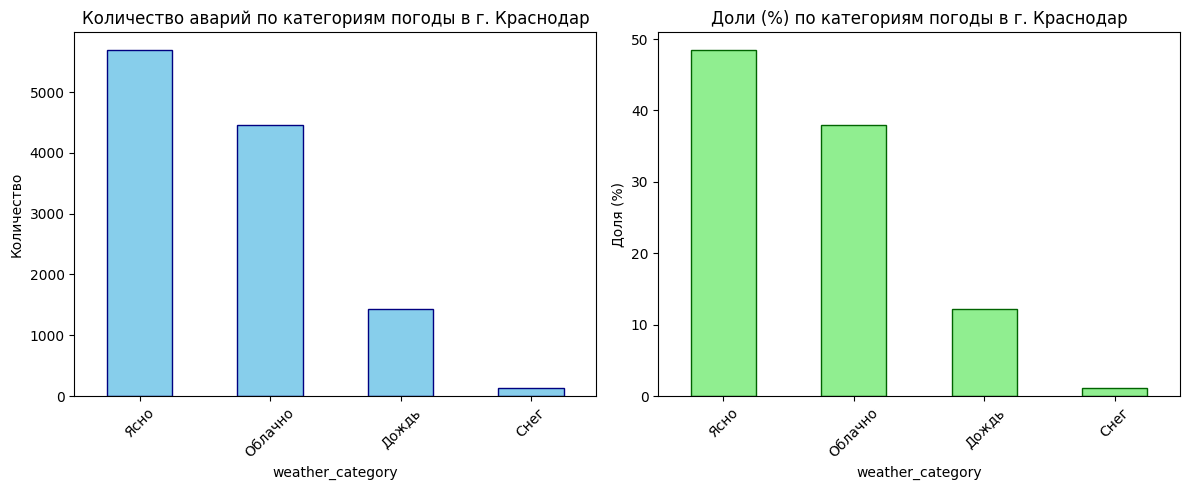

In [19]:
# считаю кол-во дтп по категории погоды
counts_kr = df_acc_kr.groupby('weather_category')['card_id'].count().sort_values(ascending=False)
# считаю доли дтп по категории погоды
proportions_kr = counts_kr / counts_kr.sum() * 100

# делаю графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график: количества
counts_kr.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество аварий по категориям погоды в г. Краснодар')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)

# Правый график: доли
proportions_kr.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) по категориям погоды в г. Краснодар')
ax2.set_ylabel('Доля (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

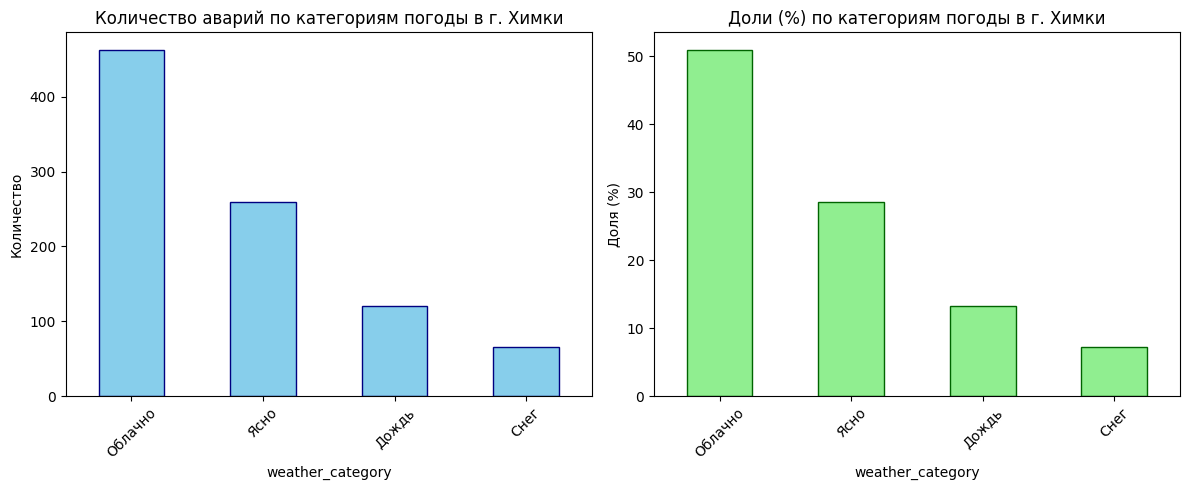

In [20]:
# считаю кол-во дтп по категории погоды
counts_him = df_acc_him.groupby('weather_category')['card_id'].count().sort_values(ascending=False)
# считаю доли дтп по категории погоды
proportions_him = counts_him / counts_him.sum() * 100

# делаю графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левый график: количества
counts_him.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество аварий по категориям погоды в г. Химки')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)

# Правый график: доли
proportions_him.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) по категориям погоды в г. Химки')
ax2.set_ylabel('Доля (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Видно, что в Краснодаре больше всего ДТП в ясную погоду, а в Химках - в Облачную. Скорее всего из-за того, что на юге России больше солнечный дней, чем на севере (Московская область). Поэтому максимальное кол-во ДТП приходится на тот тип погоды, который превалирует в выбранном регионе.

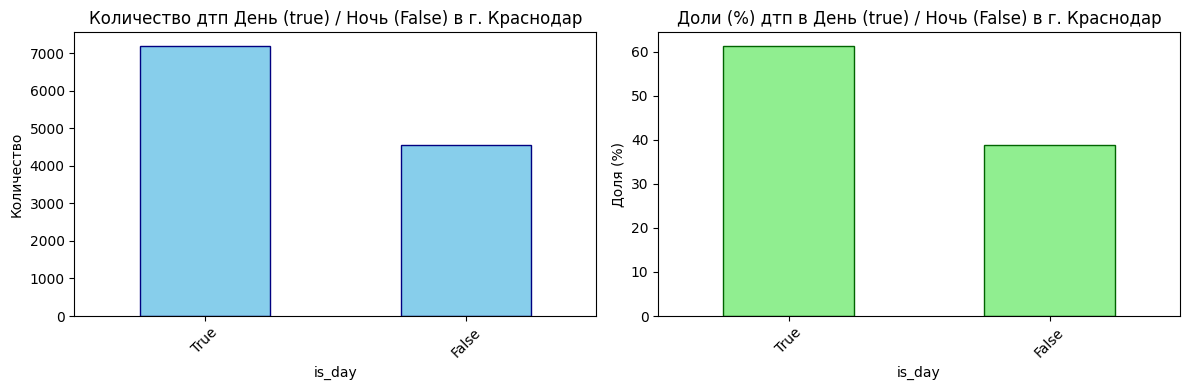

In [21]:
# делаю графики по кол-ву дтп день/ночь для Краснодара
cnt_kr = df_acc_kr.groupby('is_day')['card_id'].count().sort_values(ascending=False)
share_kr = cnt_kr / cnt_kr.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# левый график: количества по is_day
cnt_kr.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество дтп День (true) / Ночь (False) в г. Краснодар')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)

# правый график: доля по is_day
share_kr.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) дтп в День (true) / Ночь (False) в г. Краснодар')
ax2.set_ylabel('Доля (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

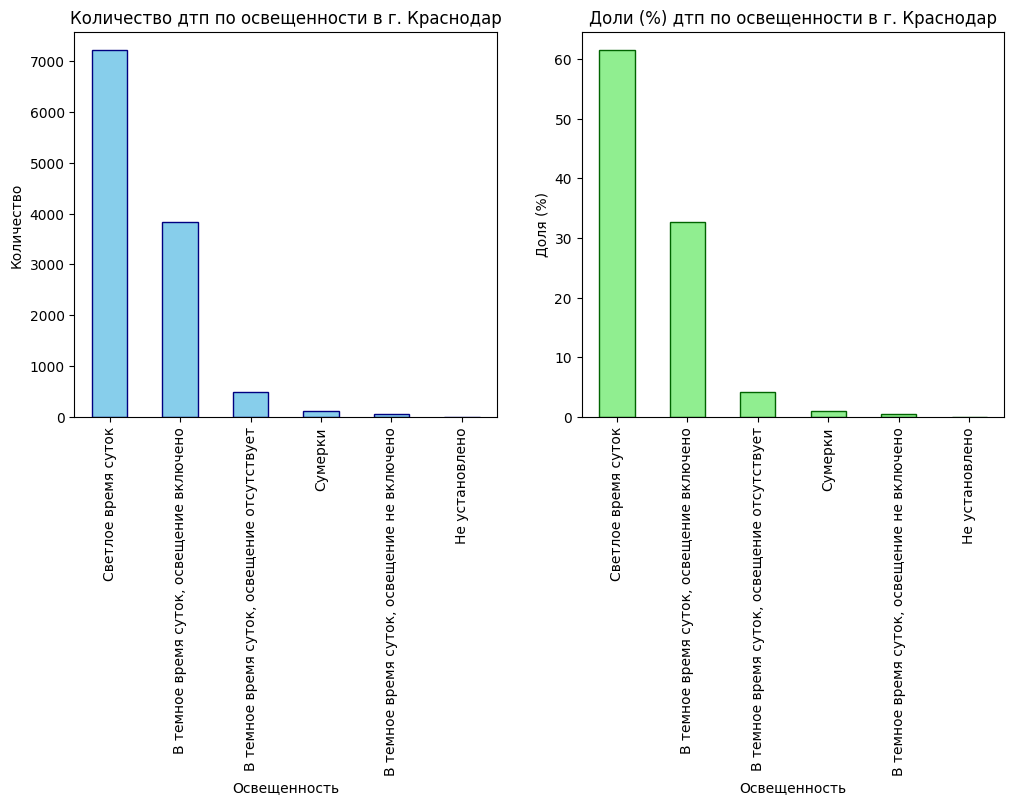

In [22]:
# делаю графики по освещенности в Краснодаре
lightning_kr = df_acc_kr.groupby('lighting_conditions')['card_id'].count().sort_values(ascending=False)
share_light_kr = lightning_kr / lightning_kr.sum() *100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# левый график: количества по освещенности
lightning_kr.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество дтп по освещенности в г. Краснодар')
ax1.set_ylabel('Количество')
ax1.set_xlabel('Освещенность')
ax1.tick_params(axis='x', rotation=90)

# правый график: доля по освещенности
share_light_kr.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) дтп по освещенности в г. Краснодар')
ax2.set_ylabel('Доля (%)')
ax2.set_xlabel('Освещенность')
ax2.tick_params(axis='x', rotation=90)

plt.show()

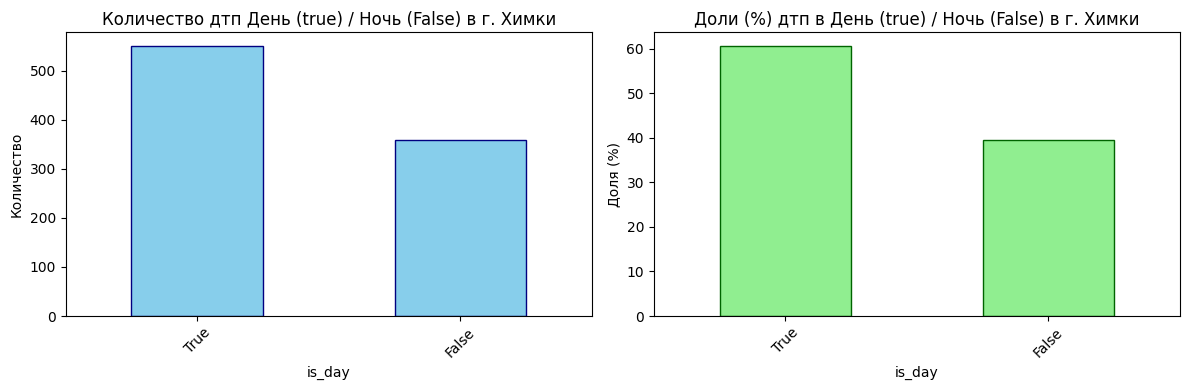

In [23]:
# делаю графики по кол-ву дтп день/ночь для Химок
cnt_him = df_acc_him.groupby('is_day')['card_id'].count().sort_values(ascending=False)
share_him = cnt_him / cnt_him.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# левый график: количества по is_day
cnt_him.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество дтп День (true) / Ночь (False) в г. Химки')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=45)

# правый график: доля по is_day
share_him.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) дтп в День (true) / Ночь (False) в г. Химки')
ax2.set_ylabel('Доля (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

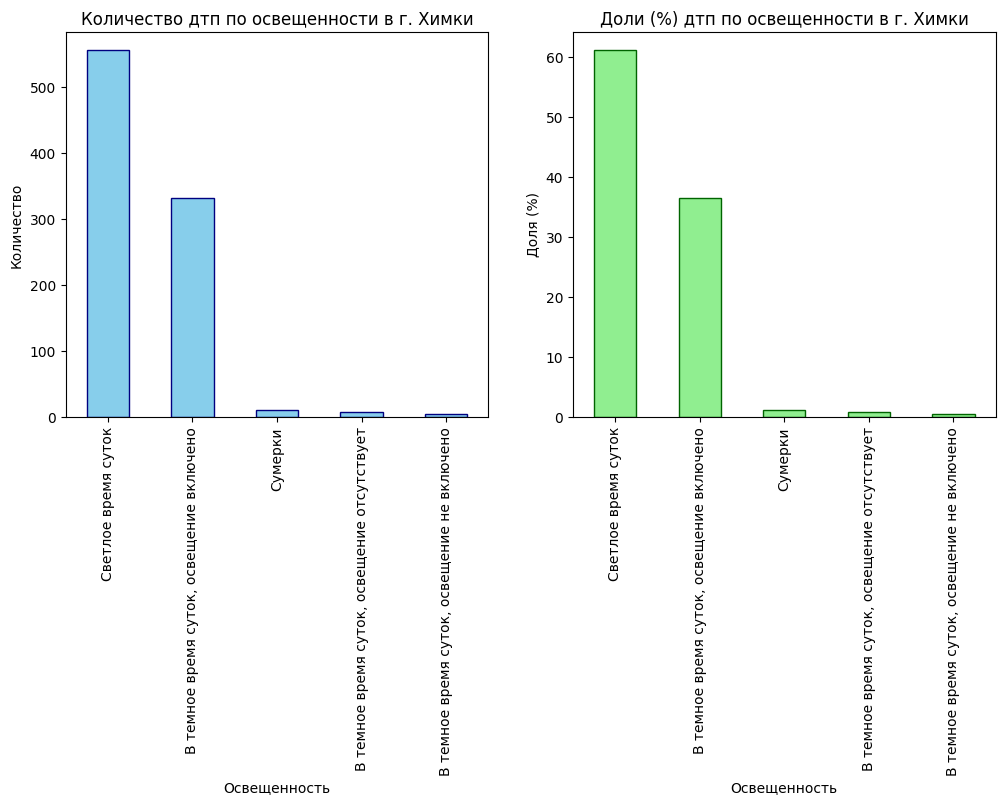

In [24]:
# делаю графики по освещенности в Химках
lightning_him = df_acc_him.groupby('lighting_conditions')['card_id'].count().sort_values(ascending=False)
share_light_him = lightning_him / lightning_him.sum() *100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# левый график: количества по освещенности
lightning_him.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='navy')
ax1.set_title('Количество дтп по освещенности в г. Химки')
ax1.set_ylabel('Количество')
ax1.set_xlabel('Освещенность')
ax1.tick_params(axis='x', rotation=90)

# правый график: доля по освещенности
share_light_him.plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='darkgreen')
ax2.set_title('Доли (%) дтп по освещенности в г. Химки')
ax2.set_ylabel('Доля (%)')
ax2.set_xlabel('Освещенность')
ax2.tick_params(axis='x', rotation=90)

plt.show()

In [25]:
print(f'Доля дтп в Краснодаре днем: {round(share_kr.iloc[0], 2)}')
print(f'Доля дтп в Химках днем: {round(share_him.iloc[0], 2)}')
print(f'Доля дтп в Краснодаре в светлое время суток: {round(share_light_kr.iloc[0], 2)}')
print(f'Доля дтп в Химках в светлое время суток: {round(share_light_him.iloc[0], 2)}')

Доля дтп в Краснодаре днем: 61.3
Доля дтп в Химках днем: 60.62
Доля дтп в Краснодаре в светлое время суток: 61.49
Доля дтп в Химках в светлое время суток: 61.06


Анализ по категории `is_day` из данных по погоде и по категории Освещенность из данных гибдд показывают, что 61% всех ДТП (что в Краснодаре, что в Химках) произошли в дневное / светлое время суток.

### 2. Погода, Состояние дороги и Тяжесть ДТП

In [26]:
# Функция расчета статистики по погоде, состоянию дороги и тяжести дтп по городу
def analyze_severity_city(df, city_name):
    print(f"\n--- Анализ для города: {city_name} ---")
    
    res = df.groupby(['weather_category', 'road_condition_group']).agg(
        mean=('total_victims', 'mean'),
        count=('card_id', 'nunique'),
        std=('total_victims', 'std')
    ).reset_index()
    
    res['se'] = res['std'] / np.sqrt(res['count'])
    res['ci_lower'] = res['mean'] - (1.96 * res['se']) # левая граница доверительного интервала
    res['ci_upper'] = res['mean'] + (1.96 * res['se']) # правая граница доверительного интервала

    # Фильтрую, чтобы убрать слишком малые кол-ва ДТП
    res = res[res['count'] > 5]
    
    return res.sort_values('mean', ascending=False).head(5)

In [27]:
top_krasnodar = analyze_severity_city(df_acc_kr, 'Краснодар')
print("\nТоп-5 опасных сочетаний Погоды и Состояния дороги (Краснодар):")
print(top_krasnodar[['weather_category', 'road_condition_group', 'count', 'mean', 'ci_lower', 'ci_upper']])


--- Анализ для города: Краснодар ---

Топ-5 опасных сочетаний Погоды и Состояния дороги (Краснодар):
   weather_category road_condition_group  count      mean  ci_lower  ci_upper
2           Облачно           Гололедица     14  1.642857  1.156331  2.129383
5           Облачно              Снежное     13  1.615385  1.197924  2.032846
12             Ясно           Гололедица     11  1.545455  1.139137  1.951772
13             Ясно               Мокрое    228  1.434211  1.307002  1.561419
10             Снег              Снежное     15  1.400000  1.027134  1.772866


In [28]:
top_khimki = analyze_severity_city(df_acc_him, 'Химки')
print("\nТоп-5 опасных сочетаний Погоды и Состояния дороги (Химки):")
print(top_khimki[['weather_category', 'road_condition_group', 'count', 'mean', 'ci_lower', 'ci_upper']])


--- Анализ для города: Химки ---

Топ-5 опасных сочетаний Погоды и Состояния дороги (Химки):
   weather_category road_condition_group  count      mean  ci_lower  ci_upper
3             Дождь                Сухое     28  1.321429  1.001782  1.641075
10             Снег               Мокрое     38  1.289474  1.013791  1.565156
4           Облачно           Гололедица     21  1.285714  1.045937  1.525492
9              Снег           Гололедица     12  1.250000  0.994106  1.505894
1             Дождь               Мокрое     90  1.222222  1.099202  1.345243


1. **Краснодар: Зима как ЧП и "Ловушка ясной погоды"**

- **Зимний пик**: Топ-3 по тяжести теперь занимают зимние условия ("Гололедица" и "Снежное"). Тяжесть достигает 1.64.
    * *Инсайт*: В Краснодаре снег и лед — это чрезвычайные ситуации. Водители не имеют навыков езды по зиме, шины летние -> результат: тяжелые аварии. Даже при "Ясно + Гололедица" тяжесть высокая (1.54).
- **Массовая угроза**: "Ясно + Мокрое" (4-е место, n=228) — это единственная категория в топе с огромной выборкой.
    * *Инсайт*: В то время как зима дает пиковую тяжесть редких событий, "Ясно + Мокрое" — это системная проблема. Огромное количество аварий (228) с тяжестью 1.43. Это подтверждает гипотезу "Ложной безопасности": солнце расслабляет водителя, и он не готов к мокрому асфальту.
2. **Химки: Адаптация к зиме и Аномалия "Скользкого сухого асфальта"**

- **Зимняя устойчивость**: Зимние условия ("Снег", "Гололедица") в Химках имеют тяжесть 1.25–1.28, что значительно ниже, чем в Краснодаре (где было 1.6+).
    * *Инсайт*: Водители Химок адаптированы к зиме. Снег для них — рабочая ситуация, а не катастрофа.
- **Странная аномалия**: Лидер по тяжести — "Дождь + Сухое" (1.32, n=28).
    * *Инсайт*: Это может быть эффект "первого дождя": пыль и масло на сухом асфальте намокают, создавая скользкую пленку, хотя визуально покрытие кажется сухим. Либо это погрешность классификации ("Морось" записана как дождь). Выборка мала (28), поэтому это зона риска, но явления достойно внимания.
- **Рабочий риск**: "Дождь + Мокрое" (n=90, тяжесть 1.22) — основная массовая проблема региона.

### 3. Тяжесть ДТП и День / Ночь

In [29]:
# Добавляю столбец, группирующий показания гибдд в День/Ночь
def clean_lighting(x):
    if 'Светлое время суток' in str(x):
        return 'День (ГИБДД)'
    else:
        return 'Ночь/Сумерки (ГИБДД)'

df_final.loc[:, 'lighting_group'] = df_final['lighting_conditions'].apply(clean_lighting)

# Сводная таблица по двум источникам
report = []

# Анализ по is_day (API)
api_stats = df_final.groupby(['district_name', 'is_day']).agg(
    count=('card_id', 'nunique'),
    mean_victims=('total_victims', 'mean')
).reset_index()
api_stats['source'] = 'API (is_day)'
api_stats['period'] = api_stats['is_day'].map({True: 'День (API)', False: 'Ночь (API)'})

# Анализ по lighting_group (ГИБДД)
gibdd_stats = df_final.groupby(['district_name', 'lighting_group']).agg(
    count=('card_id', 'nunique'),
    mean_victims=('total_victims', 'mean')
).reset_index()
gibdd_stats['source'] = 'ГИБДД (lighting)'

gibdd_stats = gibdd_stats.rename(columns={'lighting_group': 'period'})
# Объединяю
final_report = pd.concat([api_stats[['district_name', 'source', 'period', 'count', 'mean_victims']], 
                          gibdd_stats[['district_name', 'source', 'period', 'count', 'mean_victims']]])

# Сортирую
print(final_report.sort_values(['district_name', 'source', 'period']))

  district_name            source                period  count  mean_victims
1     Краснодар      API (is_day)            День (API)   7198      1.219505
0     Краснодар      API (is_day)            Ночь (API)   4544      1.370819
0     Краснодар  ГИБДД (lighting)          День (ГИБДД)   7220      1.229363
1     Краснодар  ГИБДД (lighting)  Ночь/Сумерки (ГИБДД)   4522      1.355816
3         Химки      API (is_day)            День (API)    551      1.183303
2         Химки      API (is_day)            Ночь (API)    358      1.195531
2         Химки  ГИБДД (lighting)          День (ГИБДД)    555      1.185586
3         Химки  ГИБДД (lighting)  Ночь/Сумерки (ГИБДД)    354      1.192090


C:\Users\DrGremlin\AppData\Local\Temp\ipykernel_6228\376248892.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'lighting_group'] = df_final['lighting_conditions'].apply(clean_lighting)


Интерпретация результатов  
**1. Качество данных — Отличное!**


Данные API (is_day) и ГИБДД (lighting_conditions) очень хорошо совпадают. Разница в количестве ДТП минимальна (например, в Краснодаре 7198 vs 7220). Это значит, что оба источника надежны, и мы можем использовать любой. Обычно удобнее использовать is_day (API), так как это бинарный признак.

**2. Краснодар: "Ночной фактор"**

- День: 1.22 пострадавшего на ДТП.
- Ночь: 1.37 пострадавшего на ДТП.

Вывод: В Краснодаре ночные аварии на 12% тяжелее (тяжелее последствия). Это классическая картина: ночью меньше машин, водители разгоняются, расслабляются, хуже видят или чаще садятся пьяными за руль.

**3. Химки: "Парадокс стабильности"**

- День: 1.18
- Ночь: 1.2

Вывод: В Химках время суток почти не влияет на тяжесть аварий. Это нетипично.  
*Гипотеза*: Возможно, в Химках (как спутнике Москвы) плотность трафика высока даже ночью (фуры, транзит по Ленинградскому шоссе/М11), что мешает водителям сильно разгоняться даже в темноте. Или же освещение улиц в Химках организовано значительно лучше, чем в Краснодаре, нивелируя фактор темноты.

**4. Сравнение городов**

Краснодар в среднем "тяжелее" по последствиям (1.22-1.37), чем Химки (1.18-1.2).

### 4. Тип ДТП и Погода

In [30]:
# смотрю распределение по типам ДТП
df_final['accident_type'].value_counts()

accident_type
Столкновение                                                                                                             5786
Наезд на пешехода                                                                                                        4778
Наезд на препятствие                                                                                                      622
Наезд на велосипедиста                                                                                                    521
Падение пассажира                                                                                                         371
Наезд на стоящее ТС                                                                                                       315
Опрокидывание                                                                                                             121
Съезд с дороги                                                                                          

In [31]:
# Функция для анализа типа дтп, погоды и тяжести по городу
def analyze_type_weather(df, city_name):
    print(f"\n{'='*50}\nТип ДТП и Погода: {city_name}\n{'='*50}")
    
    city_df = df[df['district_name'] == city_name].copy()
    
    # Беру топ-5 самых частых типов ДТП в городе, чтобы не засорять таблицу редкими
    top_types = city_df['accident_type'].value_counts().head(5).index
    city_df = city_df[city_df['accident_type'].isin(top_types)]
    
    # Строю таблицу: строки - Погода, Столбцы - Тип ДТП
    # Считаю проценты по строке (normalize='index'), чтобы увидеть профиль погоды
    cross = pd.crosstab(city_df['weather_category'], city_df['accident_type'], normalize='index') * 100
    
    # Округляю
    display(cross.round(1))
    
    # 3. Дополнительно: проверяю Тяжесть разных типов ДТП
    print("\nСредняя тяжесть (пострадавших) по типам ДТП:")
    display(city_df.groupby('accident_type')['total_victims'].mean().round(2).sort_values(ascending=False))

In [32]:
analyze_type_weather(df_final, 'Краснодар')
analyze_type_weather(df_final, 'Химки')


Тип ДТП и Погода: Краснодар


accident_type,Наезд на велосипедиста,Наезд на пешехода,Наезд на препятствие,Падение пассажира,Столкновение
weather_category,,,,,
Дождь,2.6,46.4,3.8,2.6,44.6
Облачно,4.1,39.5,5.1,3.4,47.9
Снег,0.7,55.8,2.9,2.9,37.7
Ясно,5.3,36.5,4.8,3.2,50.2



Средняя тяжесть (пострадавших) по типам ДТП:


accident_type
Столкновение              1.49
Наезд на препятствие      1.40
Наезд на пешехода         1.04
Наезд на велосипедиста    1.03
Падение пассажира         1.03
Name: total_victims, dtype: float64


Тип ДТП и Погода: Химки


accident_type,Наезд на велосипедиста,Наезд на пешехода,Наезд на препятствие,Наезд на стоящее ТС,Столкновение
weather_category,,,,,
Дождь,2.6,43.6,13.7,1.7,38.5
Облачно,2.5,43.8,9.6,2.9,41.3
Снег,0.0,48.4,10.9,1.6,39.1
Ясно,2.8,47.6,8.0,1.2,40.4



Средняя тяжесть (пострадавших) по типам ДТП:


accident_type
Столкновение              1.37
Наезд на препятствие      1.23
Наезд на стоящее ТС       1.21
Наезд на пешехода         1.04
Наезд на велосипедиста    1.00
Name: total_victims, dtype: float64

1. **Пешеходы — главные жертвы зимы**

- И в Краснодаре, и в Химки доля **наездов на пешеходов** резко растет при Снеге.
- **Краснодар**: 36.5% (Ясно) -> 55.8% (Снег). Это колоссальный скачок!
- **Химки**: 47.6% (Ясно) -> 48.4% (Снег).

**Вывод**: В снегопад водителям сложнее затормозить, а пешеходы (часто в капюшонах, шапках) хуже видят и слышат машины. Пешеходы становятся самым уязвимым звеном в зимний период.

2. **"Потеря управления" характерна для Химок, но не для Краснодара**

- **Химки**: Доля Наездов на препятствие при Дожде (13.7%) и Снеге (10.9%) почти в полтора раза выше, чем в ясную погоду (8.0%). Это классический сценарий: сносит машину, она летит в отбойник/столб.
- **Краснодар**: Здесь доля наездов на препятствия почти не меняется (и остается низкой ~3-5%), зато растет доля Столкновений.
    * *Гипотеза*: Возможно, в Краснодаре (южный город) реже бывают гололедица, но чаще слякоть/мокрая дорога, где тормозной путь увеличивается, вызывая "паровозики" (столкновения), но не полный снос в кювет. А в Химках зима жестче, и сносит машину чаще.
- 
3. **Тяжесть аварий**

Самые тяжелые аварии — **Столкновения** (1.49 и 1.37 пострадавших). Это логично: удар "лоб в лоб" или "в бок" переносится хуже, чем наезд на пешехода (где часто страдает один человек).

### 5. Алкоголь и Время суток

In [33]:
# смотрю топ-10 значений в колонке с уровнем алкоголя
print(df_final['alcohol_level'].value_counts(dropna=False).head(10))

alcohol_level
NaN    8958
00     3043
88       63
10       40
09       35
17       32
11       31
14       28
20       28
16       27
Name: count, dtype: int64


'00' - трезв

Буду предполагать, что пустые значения в колонке alcohol_level - это трезвые, т.к. если бы было подозрение на алкогольное опьянение, то было бы проведено осведетельствование и зафиксировано в протоколе (был бы код).

Создаю колонку `is_drunk'.

In [34]:
df_final['is_drunk'] = df_final['alcohol_level'].apply(
    lambda x: 'Пьян' if pd.notna(x) and x != '00' else 'Трезв'
)

df_final['is_drunk'].value_counts()

C:\Users\DrGremlin\AppData\Local\Temp\ipykernel_6228\2690831594.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['is_drunk'] = df_final['alcohol_level'].apply(


is_drunk
Трезв    12001
Пьян       650
Name: count, dtype: int64

In [35]:
# Делаю сводную таблицу по кол-ву пьяных днем/ночью в обоих городах
drunk_pivot = pd.pivot_table(
    df_final,
    values='card_id',
    index='district_name',
    columns=['is_day', 'is_drunk'],
    aggfunc='count',
    fill_value=0
)

In [36]:
drunk_pivot

is_day        False       True       
is_drunk       Пьян Трезв  Пьян Трезв
district_name                        
Краснодар       420  4124   183  7015
Химки            31   327    16   535

In [37]:
print("\n--- Анализ алкоголя День/Ночь ---")

for city in df_final['district_name'].unique():
    print(f"\nГород: {city}")
    for is_day_status in [True, False]:
        
        # Фильтрую выборку
        subset = df_final[
            (df_final['district_name'] == city) & 
            (df_final['is_day'] == is_day_status)
        ]
        
        total = len(subset)
        drunk_count = len(subset[subset['is_drunk'] == 'Пьян'])
        percent = (drunk_count / total * 100) if total > 0 else 0
        
        time_label = "ДЕНЬ" if is_day_status else "НОЧЬ"
        print(f"{time_label}: Пьяных участников {percent:.1f}% ({drunk_count} из {total})")


--- Анализ алкоголя День/Ночь ---

Город: Краснодар
ДЕНЬ: Пьяных участников 2.5% (183 из 7198)
НОЧЬ: Пьяных участников 9.2% (420 из 4544)

Город: Химки
ДЕНЬ: Пьяных участников 2.9% (16 из 551)
НОЧЬ: Пьяных участников 8.7% (31 из 358)


Видно, что доля пьяных участников дтп с тяжелыми последствиями Ночью выше, чем Днем (причем в обоих городах доли почти совпадают).

Рост пьяных водителей ночью в 3 - 3,5 раза — это объяснение того, почему ночью тяжесть аварий выше, т.е. можно сказать:
 - **Ночной фактор — это во многом алкогольный фактор**

**Связь с тяжестью:**
- В Краснодаре рост алкоголя ночью коррелирует с ростом тяжести аварий (днем 1.22, ночью 1.37).
- В Химках парадокс: алкоголь растет так же сильно, а тяжесть почти не меняется.
- *Гипотеза*: В Химках ночью трафик плотнее (транзит), скорости ниже, поэтому пьяные водители чаще просто "целятся" в отбойники или другие машины на небольшой скорости. В Краснодаре ночью дороги свободнее, скорости выше, и пьяный водитель на скорости улетает в кювет/опрокидывается, что дает тяжелые травмы

**Типичность данных:**
Соотношение пьяных день / ночь для обоих городов выглядят похоже, как надежная бенчмарк-метрика. Интересно посмотреть, сохранится ли такая же типичность при расширении проекта на 30 городов.

### 6. Стаж и Погода

In [38]:
# Функция для анализа Стажа водителя и Погоды по городу
def analyze_exp_weather_full(df, city_name):
    print(f"\n{'='*60}\nАнализ для города: {city_name}\n{'='*60}")
    
    # Фильтрация
    city = df[
        (df['district_name'] == city_name)
    ].copy()
    
    if city.empty:
        print("Нет данных.")
        return

    # Группировка стажа
    bins = [0, 3, 6, 11, 100]
    labels = ['Новичок (0-2)', 'Молодой (3-5)', 'Опытный (6-10)', 'Ветеран (10+)']
    city['exp_group'] = pd.cut(city['driving_exp'], bins=bins, labels=labels, right=False)

    # Считаю количество
    counts = city.groupby(['exp_group', 'weather_category'], observed=True).size().unstack(fill_value=0)
    
    # Считаю доли (по строкам)
    percents = counts.div(counts.sum(axis=1), axis=0) * 100

    # Формирую итоговую таблицу
    # Создаю пустой DataFrame для результата
    result = pd.DataFrame(index=counts.index)
    
    # Прохожу по колонкам и создаю составные "Кол-во (Доля%)"
    for col in counts.columns:
        result[col] = counts[col].astype(str) + " (" + percents[col].round(1).astype(str) + "%)"
    
    # Добавляю итоговую колонку "Всего аварий"
    result['ВСЕГО ДТП'] = counts.sum(axis=1).astype(str) + " (100%)"

    display(result)


In [39]:
analyze_exp_weather_full(df_final, 'Химки')
analyze_exp_weather_full(df_final, 'Краснодар')


Анализ для города: Химки


,Дождь,Облачно,Снег,Ясно,ВСЕГО ДТП
exp_group,,,,,
Новичок (0-2),14 (13.7%),53 (52.0%),9 (8.8%),26 (25.5%),102 (100%)
Молодой (3-5),14 (11.8%),65 (54.6%),7 (5.9%),33 (27.7%),119 (100%)
Опытный (6-10),22 (13.3%),87 (52.7%),17 (10.3%),39 (23.6%),165 (100%)
Ветеран (10+),71 (13.6%),258 (49.3%),32 (6.1%),162 (31.0%),523 (100%)



Анализ для города: Краснодар


,Дождь,Облачно,Снег,Ясно,ВСЕГО ДТП
exp_group,,,,,
Новичок (0-2),169 (10.7%),646 (41.0%),22 (1.4%),738 (46.9%),1575 (100%)
Молодой (3-5),174 (12.8%),520 (38.3%),8 (0.6%),657 (48.3%),1359 (100%)
Опытный (6-10),286 (12.6%),851 (37.5%),27 (1.2%),1105 (48.7%),2269 (100%)
Ветеран (10+),810 (12.4%),2448 (37.4%),84 (1.3%),3197 (48.9%),6539 (100%)


**Выводы по "Стаж и Погода"**
1. **Химки (Север): Скрытая угроза "Опытных" и расслабленность Ветеранов**

- **Снег — аномалия "Опытных" (6-10 лет)**: Вопреки ожиданиям, в снег чаще всего попадают в ДТП не новички, а водители со стажем 6-10 лет (**10.3%**). Это выше, чем у новичков (8.8%) и ветеранов (6.1%).
    * *Инсайт*: Это критический период: водитель уже уверен в себе (прошел страх новичка), но еще не накопил "зимнюю мудрость" ветеранов.
- **Дождь**: Новички (13.7%) и Ветераны (13.6%) показывают одинаковую долю аварийности в дождь.
- **Ясно**: Ветераны лидируют по авариям в ясную погоду (**31.0%**).
    * *Инсайт*: Ветераны успешно справляются со снегом (минимальная доля 6.1%), но "ловят" аварии на сухом асфальте из-за превышения скорости и расслабленности.
2. **Краснодар (Юг): Зона риска "Молодые" (3-5 лет)**

В мягком климате главную опасность представляет не отсутствие навыков, а потеря бдительности.

- **Дождь — пик аварийности**: Группа "Молодые" (3-5 лет) показывает **максимальную** долю аварий в дождь (**12.8%**).
    * Новички (0-2) аккуратнее всех (**10.7%**). Они боятся дождя.
    * К 3-5 годам страх уходит, самоуверенность растет -> рост аварийности.
- **Снег**: Различия между группами минимальны (0.6% - 1.4%). Снег в Краснодаре — редкий форс-мажор для всех.
- **Ясно**: Наблюдается четкий тренд: чем больше стаж, тем выше доля аварий в ясную погоду (от 46.9% у новичков до 48.9% у ветеранов). Опытные водители чаще создают аварийные ситуации в "идеальных" условиях.

**Итог**:

- **Химки**: Группа "Опытные" (6-10) требует внимания в зимний период (самые высокие риски в снег). Ветераны опасны в ясную погоду.
- **Краснодар**: Самая рискованная группа в непогоду — "Молодые" (3-5 лет). Новички — самые осторожные.

### 7. Стаж и Тяжесть ДТП

In [40]:
# Функция для анализа Сатажа водителя и Тяжести дтп
def analyze_exp_severity(df, city_name):
    print(f"\n{'='*50}\nТяжесть аварий по стажу: {city_name}\n{'='*50}")
    
    # Фильтр: только водители
    city = df[
        (df['district_name'] == city_name)].copy()
    
    # Группировка стажа
    bins = [0, 3, 6, 11, 100]
    labels = ['Новичок (0-2)', 'Молодой (3-5)', 'Опытный (6-10)', 'Ветеран (10+)']
    city['exp_group'] = pd.cut(city['driving_exp'], bins=bins, labels=labels, right=False)
    
    # Группирую по стажу, беру mean от total_victims
    severity_stats = city.groupby('exp_group', observed=True).agg(
        mean_victims=('total_victims', 'mean'),
        count=('card_id', 'nunique') # кол-во аварий с их участием
    ).round(3)
    
    # вывожу данные, отсортированные по среднему кол-ву пострадавших по убыванию
    display(severity_stats.sort_values(by='mean_victims', ascending=False))

In [41]:
analyze_exp_severity(df_final, 'Краснодар')
analyze_exp_severity(df_final, 'Химки')


Тяжесть аварий по стажу: Краснодар


,mean_victims,count
exp_group,,
Молодой (3-5),1.305,1359
Новичок (0-2),1.297,1575
Опытный (6-10),1.272,2269
Ветеран (10+),1.270,6539



Тяжесть аварий по стажу: Химки


,mean_victims,count
exp_group,,
Ветеран (10+),1.205,523
Опытный (6-10),1.188,165
Молодой (3-5),1.168,119
Новичок (0-2),1.127,102


Анализ выявил принципиально разные паттерны риска для регионов с разным климатом.

1. **Химки: Феномен "Осторожного новичка"**

В условиях сложного климата (снег, гололед) работает парадоксальная зависимость: **чем больше стаж, тем тяжелее авария.**

- **Ветераны (10+)** — группа риска: Самая высокая тяжесть аварий (1.205).
- **Новички (0-2)** — самые безопасные: Минимальная тяжесть (1.127).
- *Инсайт*: В Химках новички напуганы сложными дорожными условиями и ездят предельно осторожно, на низких скоростях. Их аварии — это чаще всего легкие касания. Ветераны же избыточно самоуверенны, считают, что их опыт позволяет компенсировать погодные риски, что приводит к более тяжелым последствиям при потере контроля.
2. **Краснодар: Зона "Ложной уверенности" (3-5 лет)**
  
В более мягких южных условиях картина меняется.

- **Пик опасности — "Молодые" (3-5 лет)**: Эта группа показывает максимум тяжести (1.305).
    * *Инсайт*: Это классический период "торжествующего ученика". Страх новичка прошел, уверенность выросла, а мастерство и ответственность еще не достигли пика. Именно эта группа, а не новички, создает самые тяжелые аварии.
- **Новички (0-2)**: Тяжесть чуть ниже (1.297), чем у молодых. Они все еще осторожны.
- **Ветераны**: Показывают лучший результат (1.270). Опыт в Краснодаре реально помогает снижать тяжесть последствий.

**Итог**:

- **Для Химок**: Нужно работать с "королями дороги" — Ветеранами. Кампании против самоуверенности и напоминание о зимних рисках.
- **Для Краснодара**: Основная мишень — водители со стажем 3-5 лет. Им кажется, что они уже всё умеют, но это иллюзия. Обучение контраварийному вождению в этот период критически важно.

### 8. Гендер и Тяжесть ДТП

In [42]:
# смотрю, какие есть значения в колонке Пол и как они распределены
print(df_final['gender'].unique())
print(df_final['gender'].value_counts())

['Мужской' 'Женский' nan 'Не определен']
gender
Мужской         10214
Женский          1925
Не определен      489
Name: count, dtype: int64


In [43]:
# Функция для анализа Гендера и Тяжести дтп
def analyze_gender(df, city_name):
    print(f"\n{'='*50}\nГендерный анализ: {city_name}\n{'='*50}")
    
    city_df = df[df['district_name'] == city_name].copy()
    
    # Общее распределение по ролям и полу
    print("\n1. Распределение водителей по полу (в %):")
    gender = city_df['gender'].value_counts(normalize=True)
    print(gender.round(2))
        
    print("\n2. Статистика аварийности водителей по полу:")
    gender_stats = city_df.groupby('gender').agg(
        total_accidents=('card_id', 'nunique'),
        mean_victims=('total_victims', 'mean')
    ).round(3)
    display(gender_stats)

In [44]:
analyze_gender(df_final, 'Краснодар')
analyze_gender(df_final, 'Химки')


Гендерный анализ: Краснодар

1. Распределение водителей по полу (в %):
gender
Мужской         0.80
Женский         0.15
Не определен    0.04
Name: proportion, dtype: float64

2. Статистика аварийности водителей по полу:


,total_accidents,mean_victims
gender,,
Женский,1813,1.220
Мужской,9431,1.298
Не определен,476,1.111



Гендерный анализ: Химки

1. Распределение водителей по полу (в %):
gender
Мужской         0.86
Женский         0.12
Не определен    0.01
Name: proportion, dtype: float64

2. Статистика аварийности водителей по полу:


,total_accidents,mean_victims
gender,,
Женский,112,1.188
Мужской,783,1.189
Не определен,13,1.154


- **За рулем**: Мужчины составляют ~80-85% водителей в ДТП.
- **Тяжесть**: Мужчины-водители создают аварии с тяжестью 1.3 (Краснодар) и 1.19 (Химки). Женщины — 1.22 и 1.19 соответственно.
    * В Краснодаре мужчины опаснее женщин на ~6.5%.
    * В Химках одинаковое кол-во пострадавших на 1 ДТП как для мужчин, так и для женщин.

### 9. Гендер и Погода

In [45]:
# Функция для анализа Гендера и Погоды
def analyze_gender_weather(df, city_name):
    print(f"\n{'='*50}\nГендер и Погода: {city_name}\n{'='*50}")
    
    city_df = df[
        (df['district_name'] == city_name)].copy()
    
    # Считаю долю аварий в разную погоду для мужчин и женщин (нормирую по строке)
    gender_weather = pd.crosstab(city_df['gender'], city_df['weather_category'], normalize='index') * 100
    
    print("\nДоля аварий в разную погоду (в % по строке):")
    display(gender_weather.round(1))
    
    # Дополнительно: Тяжесть аварий в плохую погоду
    print("\nСредняя тяжесть в Снег и Дождь:")
    severe_weather = city_df[city_df['weather_category'].isin(['Снег', 'Дождь'])]
    print(severe_weather.groupby('gender')['total_victims'].mean().round(3))

In [46]:
analyze_gender_weather(df_final, 'Краснодар')
analyze_gender_weather(df_final, 'Химки')


Гендер и Погода: Краснодар

Доля аварий в разную погоду (в % по строке):


weather_category,Дождь,Облачно,Снег,Ясно
gender,,,,
Женский,10.9,40.2,1.2,47.8
Мужской,12.4,37.6,1.2,48.7
Не определен,13.7,37.0,0.6,48.7



Средняя тяжесть в Снег и Дождь:
gender
Женский         1.165
Мужской         1.314
Не определен    1.132
Name: total_victims, dtype: float64

Гендер и Погода: Химки

Доля аварий в разную погоду (в % по строке):


weather_category,Дождь,Облачно,Снег,Ясно
gender,,,,
Женский,7.1,52.7,6.2,33.9
Мужской,14.2,50.6,7.3,28.0
Не определен,15.4,53.8,7.7,23.1



Средняя тяжесть в Снег и Дождь:
gender
Женский         1.133
Мужской         1.268
Не определен    1.333
Name: total_victims, dtype: float64


1. **Распределение аварий по погоде (Поведенческий фактор)**

Здесь наблюдается яркая разница в стратегиях вождения мужчин и женщин.

- **Химки — Эффект "Избегания риска"**:
    * Женщины в ДТП в дождь попадают в **2 раза реже** (по доле), чем мужчины: 7.1% против 14.2%.
    * В то же время, доля аварий женщин в ясную погоду (33.9%) заметно выше, чем у мужчин (28.0%).
    * *Инсайт*: Женщины в сложном климате Химок демонстрируют модель "защитного поведения" — в дождь они либо не садятся за руль, либо выбирают максимально осторожный темп, исключающий попадание в ДТП с пострадавшими. Мужчины продолжают ездить в привычном "рабочем" режиме, невзирая на дождь.
- **Краснодар — Стабильность**:
    * Разрыв между полами в непогоду меньше. В дождь доля ДТП женщин (10.9%) ниже, чем у мужчин (12.4%), но не так критично, как в Химках. Мягкий климат позволяет обоим полам сохранять схожую мобильность.
2. **Тяжесть последствий в непогоду (Дождь + Снег)**

Мужчины-водители создают статистически более тяжелые аварии в сложных метеоусловиях.

- **Краснодар**: Мужчины (1.31 пострадавшего) против Женщин (1.17). Разница в тяжести составляет ~12%.
- **Химки**: Мужчины (1.27) против Женщин (1.13). Разница в тяжести также около 12%.

**Итог**:

Женщины демонстрируют двойную безопасность в непогоду:

- **Вероятность**: Они реже попадают в аварии в дождь (особенно в Химках).
- **Последствия**: Если авария все же происходит, тяжесть у женщин значительно ниже (1.13–1.17), чем у мужчин (1.27–1.31). Мужской стиль вождения в непогоду характеризуется избыточной уверенностью и скоростью, что ведет к более трагичным исходам.

### 10. Возраст машины и Тяжесть ДТП

Гипотеза: На старых машинах безопасность ниже (нет подушек, ABS), значит тяжесть выше.

In [47]:
# присоединяю к общей таблице таблицу с транспортными средствами
df_full = df_final.merge(df_ts[['card_id', 'vehicle_number', 'vehicle_brand', 'vehicle_model', 'manufacture_year', 'vehicle_color',
       'vehicle_category']], 
                                on=['card_id', 'vehicle_number'],
                                how='left'
                               )
# меняю тип данных для года выпуска
df_full['manufacture_year'] = pd.to_numeric(df_full['manufacture_year'])

In [48]:
# смотрю распределение даты выпуска ТС
df_full['manufacture_year'].value_counts()

manufacture_year
2008.0    891
2013.0    887
2012.0    853
2011.0    765
2007.0    691
2014.0    661
2010.0    582
2006.0    489
2018.0    473
2019.0    469
2015.0    424
2017.0    423
2005.0    414
2016.0    394
2004.0    348
2009.0    338
2003.0    303
2002.0    301
2021.0    297
2020.0    296
2001.0    248
2000.0    241
2023.0    201
1999.0    143
1998.0    141
2022.0    119
1997.0    105
1996.0    102
2024.0    101
1995.0     73
1994.0     62
1993.0     51
1992.0     47
1991.0     41
1990.0     40
1989.0     37
1985.0     35
1986.0     28
1987.0     26
1988.0     24
1982.0     17
2025.0     12
1981.0     11
1983.0     11
1984.0     11
1980.0      8
1978.0      3
1972.0      3
1973.0      3
1979.0      3
1975.0      2
1977.0      2
1976.0      2
1974.0      2
1970.0      2
1971.0      1
1900.0      1
Name: count, dtype: int64

In [49]:
# удаляю выброс 1900 года выпуска (скорее всего опечатка в протоколе)
df_full = df_full[df_full['manufacture_year'] != 1900]
df_full['manufacture_year'].describe()

count    12257.000000
mean      2009.860977
std          7.646049
min       1970.000000
25%       2006.000000
50%       2011.000000
75%       2015.000000
max       2025.000000
Name: manufacture_year, dtype: float64

In [50]:
# Функция для анализа возраста ТС и Тяжести дтп
def analyze_car_age(df, city_name):
    print(f"\n{'='*50}\nВозраст авто и Тяжесть: {city_name}\n{'='*50}")
    
    # Фльтрую по городу и по строкам, где есть год выпуска
    city_age = df[
        (df['district_name'] == city_name) &
        (df['manufacture_year'].notna())
    ].copy()
    
    # Считаю возраст машины (беру 2025 как текущий год, так как данные за 2025 есть)
    city_age['car_age'] = 2025 - city_age['manufacture_year']
    
    # Группирую по возрасту, разбиваю на группы: 0-5 лет, 6-10, 11-20, 21+    
    bins = [0, 6, 11, 21, 100]
    labels = ['Новая (0-5)', 'Средняя (6-10)', 'Старая (11-20)', 'Ретро (21+)']
    city_age['car_age_group'] = pd.cut(city_age['car_age'], bins=bins, labels=labels)
    
    age_stats = city_age.groupby('car_age_group', observed=True).agg(
        count=('card_id', 'nunique'),
        mean_victims=('total_victims', 'mean')
    ).round(3)
    
    display(age_stats.sort_values('mean_victims', ascending=False))

In [51]:
analyze_car_age(df_full, 'Краснодар')
analyze_car_age(df_full, 'Химки')


Возраст авто и Тяжесть: Краснодар


,count,mean_victims
car_age_group,,
Ретро (21+),2037,1.313
Новая (0-5),1332,1.299
Средняя (6-10),2131,1.280
Старая (11-20),5840,1.277



Возраст авто и Тяжесть: Химки


,count,mean_victims
car_age_group,,
Средняя (6-10),244,1.217
Новая (0-5),151,1.205
Старая (11-20),418,1.175
Ретро (21+),92,1.152


1. **Краснодар: Опасность "Ретро" и быстрые "Новинки"**

- **Ретро (21+)**: Максимальная тяжесть **1.31**.
    * *Инсайт*: Старые машины ("Жигули", "Москвичи" возрастом 20+) не имеют современных систем безопасности (подушки, ABS, зоны деформации). Даже при не самой высокой скорости столкновение приводит к травмам.
- **Новые (0-5)**: Второе место по тяжести (**1.30**).
    * *Инсайт*: Эффект "Ложной безопасности" работает. Водители чувствуют себя защищенными электроникой и едут быстрее, что при аварии дает высокую тяжесть.
- **Старые (11-20)**: Самые безопасные (**1.28**). Это "золотая середина": наличие базовых систем безопасности, но отсутствие страсти к гонкам.
2. **Химки: "Зона риска" — автомобили среднего возраста**

- **Лидеры по тяжести (6-10 лет)**: Тяжесть **1.22**.
    * *Инсайт*: Это самый активный возраст работы машины. Часто это такси или рабочие авто. У них уже стерты шины, могут быть мелкие неисправности тормозов, но водители эксплуатируют их в полную силу.
- **Новые (0-5)**: На втором месте (**1.21**).
- **Ретро (21+)**: Самые безопасные (**1.15**).
    * *Инсайт*: В Химках ретро-автомобили — это часто машины "выходного дня" или ухоженные экземпляры, которые зимой просто не выезжают из гаража. Отсюда низкая тяжесть.

**Общий итог**:

- **Новые машины (0-5 лет)** остаются в зоне повышенного риска в обоих городах (входят в топ-2). Технологии безопасности компенсируются скоростью и самоуверенностью.
- **Ретро-автомобили** ведут себя по-разному: на Юге (Краснодар) они смертельно опасны из-за отсутствия подушек безопасности, на Севере (Химки) — безопаснее всех, так как в непогоду на них не ездят.

### 11. Цвет авто и Тяжесть ДТП

Гипотеза: Черные машины чаще попадают в ДТП ночью (плохо видно).

In [52]:
# смотрю, какие цвета есть в данных
df_full['vehicle_color'].unique()

array(['Белый', 'Зеленый', 'Черный', 'Иные цвета', 'Серый', 'Синий',
       'Не заполнено', 'Красный', 'Коричневый', 'Фиолетовый',
       'Многоцветный', 'Желтый', nan, 'Оранжевый'], dtype=object)

In [53]:
# Функция для анализа цвета ТС и Тяжести дтп
def analyze_car_color(df, city_name):
    print(f"\n{'='*50}\nЦвет авто и ДТП: {city_name}\n{'='*50}")
    
    city_color = df[
        (df['district_name'] == city_name) &
        (df['vehicle_color'].notna())
    ].copy()
    
    # Топ-5 популярных цветов
    print("\nТоп-5 цветов по количеству ДТП:")
    print(city_color['vehicle_color'].value_counts().head(5))
    
    # Основные цвета ночью
    print("\nКол-во и тяжесть ДТП ночью для основных цветов:")
    night_drivers = city_color[city_color['is_day'] == False]
    # Оставляю только основные цвета
    # main_colors = night_drivers[night_drivers['vehicle_color'].isin(['Черный', 'Белый', 'Серый'])]
    display(night_drivers.groupby('vehicle_color').agg(
        dtp_count=('card_id', 'nunique'),
        mean_victims=('total_victims', 'mean')
        ).sort_values(by='mean_victims', ascending=False).head(5))

In [54]:
analyze_car_color(df_full, 'Краснодар')
analyze_car_color(df_full, 'Химки')


Цвет авто и ДТП: Краснодар

Топ-5 цветов по количеству ДТП:
vehicle_color
Белый         4078
Серый         2343
Черный        1453
Синий          793
Иные цвета     752
Name: count, dtype: int64

Кол-во и тяжесть ДТП ночью для основных цветов:


,dtp_count,mean_victims
vehicle_color,,
Красный,263,1.460076
Зеленый,133,1.451128
Черный,615,1.429268
Белый,1508,1.391910
Синий,330,1.384848



Цвет авто и ДТП: Химки

Топ-5 цветов по количеству ДТП:
vehicle_color
Белый         214
Черный        154
Иные цвета    141
Серый         135
Синий          73
Name: count, dtype: int64

Кол-во и тяжесть ДТП ночью для основных цветов:


,dtp_count,mean_victims
vehicle_color,,
Многоцветный,6,1.833333
Красный,17,1.294118
Синий,28,1.285714
Черный,59,1.237288
Коричневый,5,1.200000


1. **Краснодар: Яркие цвета — сигнал опасности**

- В топе по тяжести ночью — **Красный** (1.46) и **Зеленый** (1.45).
    * *Парадокс*: Обычно считают, что светлые машины безопаснее. Но яркие цвета (красный, зеленый) часто имеют низкую световозвращаемость краски в темноте (темные оттенки), либо это просто специфика парка (старые яркие машины).
- **Черный** (1.43) подтверждает статус опасного цвета (плохая видимость в темноте).
- **Белый** (1.39) — самый безопасный среди популярных. Он лучше всего виден ночью.
2. **Химки: Многоцветные и Красные**

- **Многоцветные** (2.0) и **Красные** (1.29) лидируют.
    * *Многоцветные* — это часто такси или спецтранспорт, у которого могут быть свои риски (усталость водителя).
- **Черный** (1.24) снова в зоне риска.

**Итог**: Для ночной езды белая машина — лучший выбор с точки зрения безопасности. Черные и яркоокрашенные машины (кроме белого) чаще участвуют в тяжелых ночных авариях.

## Итоговое Саммари: Факторы тяжести ДТП в регионах РФ

**Главный тезис**:  
Анализ показал, что тяжесть последствий ДТП зависит не столько от погодных условий самих по себе, сколько от психологии водителя и его адаптации к климату региона.

1. **Региональная специфика рисков**
- **Краснодар (Юг): Зона "Ложной безопасности".**
    * Основная угроза — хорошая погода. Лидеры по тяжести — сочетания "Ясно + Мокрое" и "Ясно + Гололедица". Водители расслабляются на солнце и теряют бдительность на скользком покрытии.
    * Снег — ЧП. Зимние условия вызывают резкий скачок тяжести аварий (до 1.64), так как водители не имеют навыков зимнего вождения и скорее всего не меняют летнюю резину.
- **Химки (Север): Зона "Адаптации и Скорости".**
    * Водители адаптированы к зиме: тяжесть аварий в снег ниже, чем в Краснодаре.
    * Основные риски связаны с "рабочими" факторами: автомобили среднего возраста (такси/коммерция), превышение скорости на сухом асфальте (ветераны) и аномалия "скользкого сухого асфальта" в начале дождя.
2. **Человеческий фактор: Парадоксы опыта**
- **Химки**: Опаснее всего быть пешеходом зимой (рост доли наездов до 48%). Среди водителей самую тяжелую аварию создают **Ветераны (10+ лет)** из-за самоуверенности, тогда как новички ездят предельно осторожно.
- **Краснодар**: Самая рискованная группа — **"Молодые" водители (3-5 лет стажа)**. Это период "торжествующего ученика": страх ушел, а мастерство еще не пришло.
- **Гендер**: Женщины демонстрируют модель "защитного поведения" (реже попадают в ДТП в непогоду, тяжесть на 12% ниже). Мужчины чаще попадают в тяжелые аварии из-за агрессивного стиля вождения.
3. **Фактор "Ночь и Алкоголь"**
- Ночной фактор — это во многом алкогольный фактор. Доля пьяных водителей ночью растет в 3-3.5 раза.
- В Краснодаре это ведет к росту тяжести аварий (+12% ночью). В Химках тяжесть стабильна день/ночь, возможно, из-за плотного ночного трафика и лучшего уличного освещения.
4. **Технический фактор: Машина как риск**
- **Парадокс новых машин**: Автомобили 0-5 лет на 2м месте по тяжести аварий в обоих городах. Современные системы безопасности создают иллюзию неуязвимости, провоцируя рост скоростей.
- **Ретро-авто**: На юге они смертельно опасны (отсутствие подушек безопасности), на севере — самые безопасные (используются редко и аккуратно).
- **Цвет**: Белый цвет — самый безопасный для ночного вождения. Черные и яркие цвета (красный, зеленый) увеличивают тяжесть ночных аварий.
5. **Рекомендации для повышения безопасности**
- **Информационные кампании**: В Краснодаре — предупреждения об опасности мокрого асфальта в солнечную погоду. В Химки — борьба с самоуверенностью ветеранов и зимняя безопасность пешеходов.
- **Инфраструктура**: Улучшение освещения пешеходных переходов зимой (актуально для обоих регионов, особенно Химок).
